In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

# Create directory for exported charts
os.makedirs('../reports/charts', exist_ok=True)

# Connect to the SQLite database
db_path = '../bluestock_mf.db'
conn = sqlite3.connect(db_path)

# Set global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Fetch NAV data
query_nav = """
SELECT n.date, n.nav, f.scheme_name 
FROM nav_history n
JOIN fund_master f ON n.amfi_code = f.amfi_code
WHERE n.date >= '2022-01-01' AND n.date <= '2026-12-31'
"""
df_nav = pd.read_sql(query_nav, conn, parse_dates=['date'])

# Plotly line chart
fig1 = px.line(df_nav, x='date', y='nav', color='scheme_name', 
               title='Daily NAV Trend (2022-2026)',
               labels={'nav': 'Net Asset Value (INR)', 'date': 'Date'})

# Annotate market events
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
fig1.add_vrect(x0="2024-06-01", x1="2024-09-30", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")

fig1.write_image('../reports/charts/nav_trend_analysis.png', width=1200, height=600)
fig1.show()

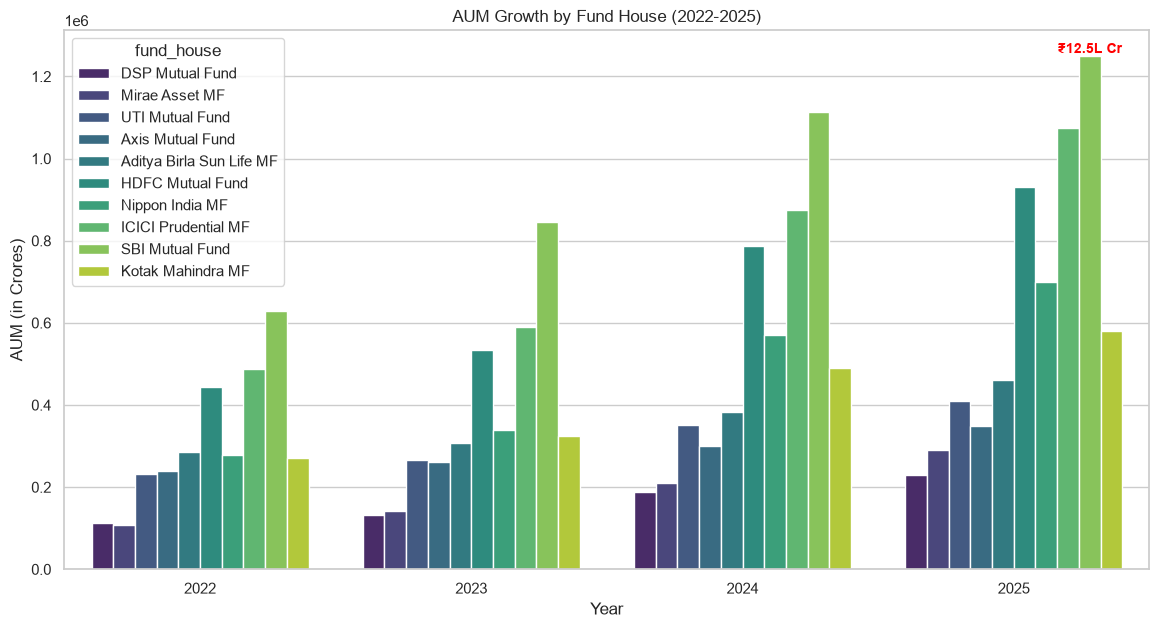

In [8]:
# Fetch AUM data
query_aum = """
SELECT date, fund_house, aum_crore 
FROM aum_by_fund_house 
"""
df_aum = pd.read_sql(query_aum, conn, parse_dates=['date'])

# Extract year from the date column and filter for 2022-2025
df_aum['year'] = df_aum['date'].dt.year
df_aum = df_aum[(df_aum['year'] >= 2022) & (df_aum['year'] <= 2025)]

# Keep only the latest AUM record per year for each fund house to prevent duplicated sums
df_aum = df_aum.sort_values('date').drop_duplicates(subset=['year', 'fund_house'], keep='last')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum, x='year', y='aum_crore', hue='fund_house', palette='viridis')
plt.title('AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (in Crores)')
plt.xlabel('Year')

# Highlight SBI at 12.5L Cr (which equals 1,250,000 Crores)
for p in ax.patches:
    if p.get_height() >= 1250000:
        ax.annotate('₹12.5L Cr', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

plt.savefig('../reports/charts/aum_growth_bar.png', bbox_inches='tight')
plt.show()

In [11]:
# Fetch SIP inflows using actual column names: month, sip_inflow_crore[cite: 7]
query_sip = "SELECT month, sip_inflow_crore FROM monthly_sip_inflows"
df_sip = pd.read_sql(query_sip, conn)

# Ensure the date is in datetime format and sort chronologically
df_sip['month'] = pd.to_datetime(df_sip['month'])
df_sip = df_sip.sort_values('month')

# Plotly line chart
fig2 = px.line(df_sip, x='month', y='sip_inflow_crore', markers=True, 
               title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
               labels={'month': 'Month', 'sip_inflow_crore': 'SIP Amount (Cr)'})

# Annotate All-Time High
max_sip = df_sip['sip_inflow_crore'].max()
max_date = df_sip.loc[df_sip['sip_inflow_crore'].idxmax(), 'month']

fig2.add_annotation(x=max_date, y=max_sip, text=f"₹{max_sip:,.0f} Cr (ATH)", 
                    showarrow=True, arrowhead=1, ax=-40, ay=-40)

fig2.write_image('../reports/charts/sip_inflow_trend.png', width=1000, height=500)
fig2.show()

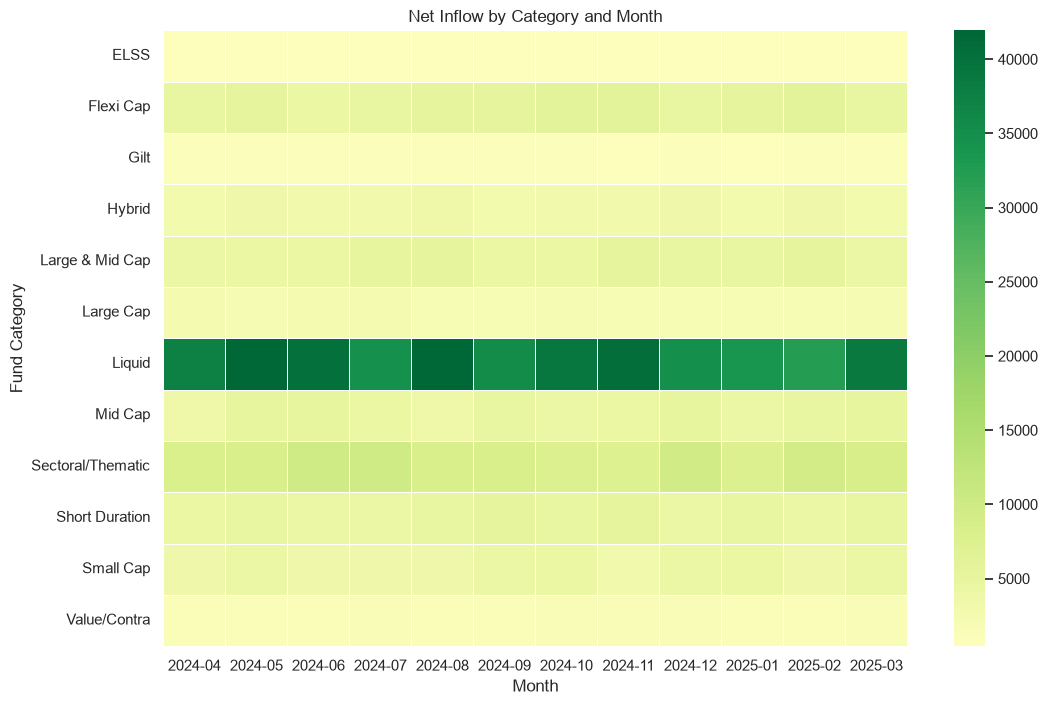

In [12]:
# Updated to use net_inflow_crore[cite: 7]
query_cat = "SELECT month, category, net_inflow_crore FROM category_inflows"
df_cat = pd.read_sql(query_cat, conn)

# Pivot data for heatmap formatting
pivot_cat = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_cat, cmap='RdYlGn', center=0, annot=False, linewidths=.5)
plt.title('Net Inflow by Category and Month')
plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.savefig('../reports/charts/category_inflow_heatmap.png', bbox_inches='tight')
plt.show()

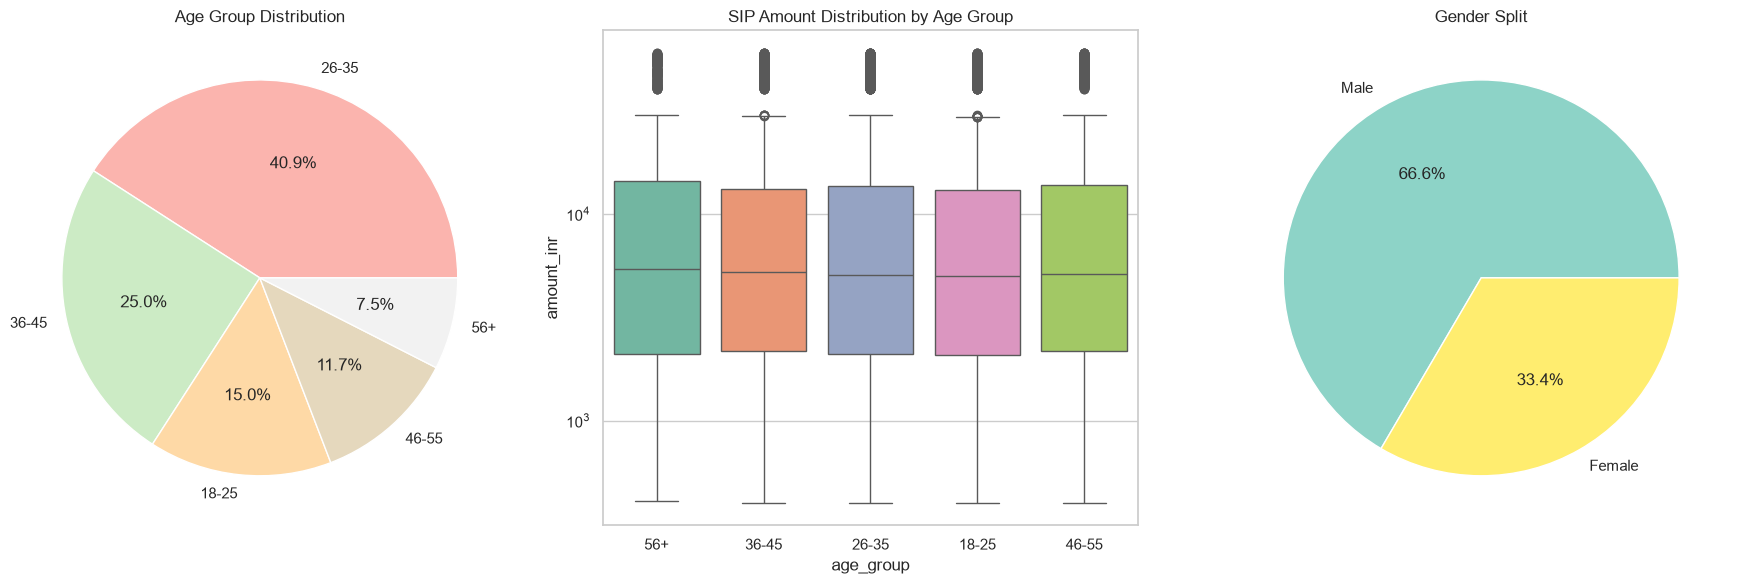

In [13]:
# Updated to use amount_inr[cite: 7]
query_demographics = """
SELECT age_group, gender, amount_inr 
FROM investor_transactions 
WHERE transaction_type = 'SIP'
"""
df_demo = pd.read_sql(query_demographics, conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Age Group Distribution Pie Chart
df_demo['age_group'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], cmap='Pastel1')
axes[0].set_title('Age Group Distribution')
axes[0].set_ylabel('')

# 2. SIP Amount by Age Group Box Plot
sns.boxplot(data=df_demo, x='age_group', y='amount_inr', ax=axes[1], palette='Set2')
axes[1].set_title('SIP Amount Distribution by Age Group')
axes[1].set_yscale('log')

# 3. Gender Split Pie Chart
df_demo['gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2], cmap='Set3')
axes[2].set_title('Gender Split')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/charts/investor_demographics.png')
plt.show()

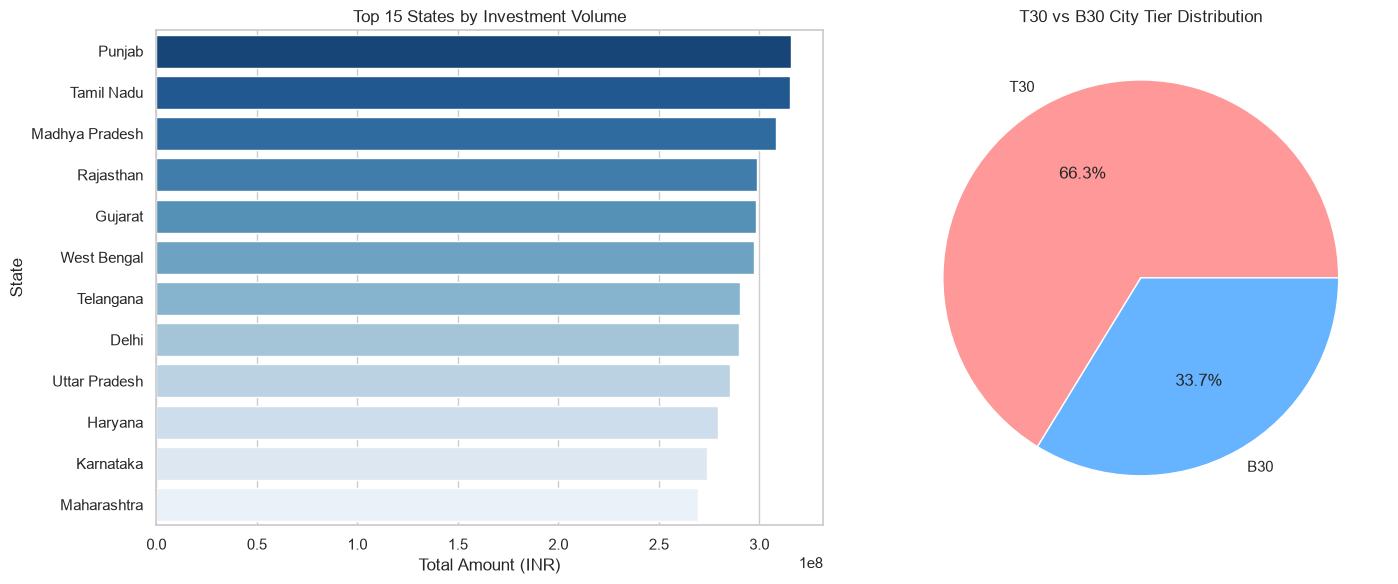

In [14]:
# Updated to use amount_inr[cite: 7]
query_geo = "SELECT state, city_tier, amount_inr FROM investor_transactions"
df_geo = pd.read_sql(query_geo, conn)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. SIP by State Horizontal Bar Chart
state_vol = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=state_vol.values, y=state_vol.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 15 States by Investment Volume')
axes[0].set_xlabel('Total Amount (INR)')
axes[0].set_ylabel('State')

# 2. T30 vs B30 City Tier Pie Chart
df_geo['city_tier'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#ff9999','#66b3ff'])
axes[1].set_title('T30 vs B30 City Tier Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/charts/geographic_distribution.png')
plt.show()

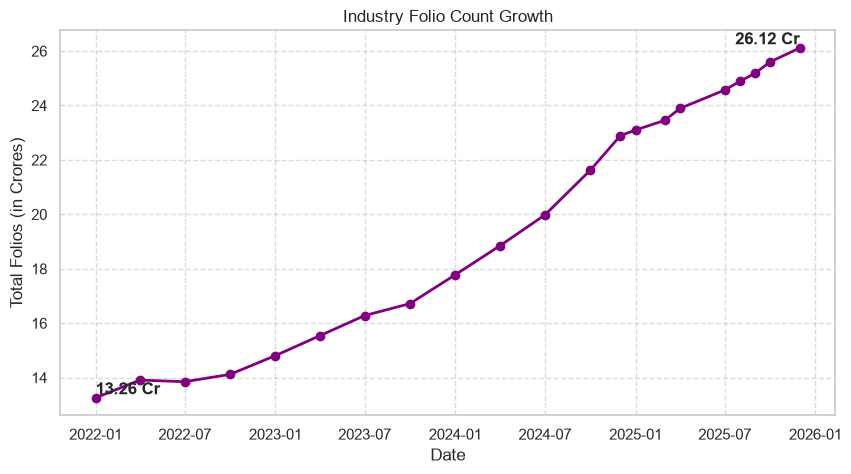

In [15]:
# Updated to use month and total_folios_crore[cite: 7]
query_folio = "SELECT month, total_folios_crore FROM industry_folio_count"
df_folio = pd.read_sql(query_folio, conn, parse_dates=['month'])
df_folio = df_folio.sort_values('month')

plt.figure(figsize=(10, 5))
plt.plot(df_folio['month'], df_folio['total_folios_crore'], marker='o', color='purple', linewidth=2)
plt.title('Industry Folio Count Growth')
plt.ylabel('Total Folios (in Crores)')
plt.xlabel('Date')

# Annotate the start and end milestones dynamically
start_date = df_folio['month'].min()
end_date = df_folio['month'].max()
start_val = df_folio['total_folios_crore'].iloc[0]
end_val = df_folio['total_folios_crore'].iloc[-1]

plt.text(start_date, start_val, f'{start_val} Cr', va='bottom', fontweight='bold')
plt.text(end_date, end_val, f'{end_val} Cr', va='bottom', ha='right', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../reports/charts/folio_count_growth.png', bbox_inches='tight')
plt.show()

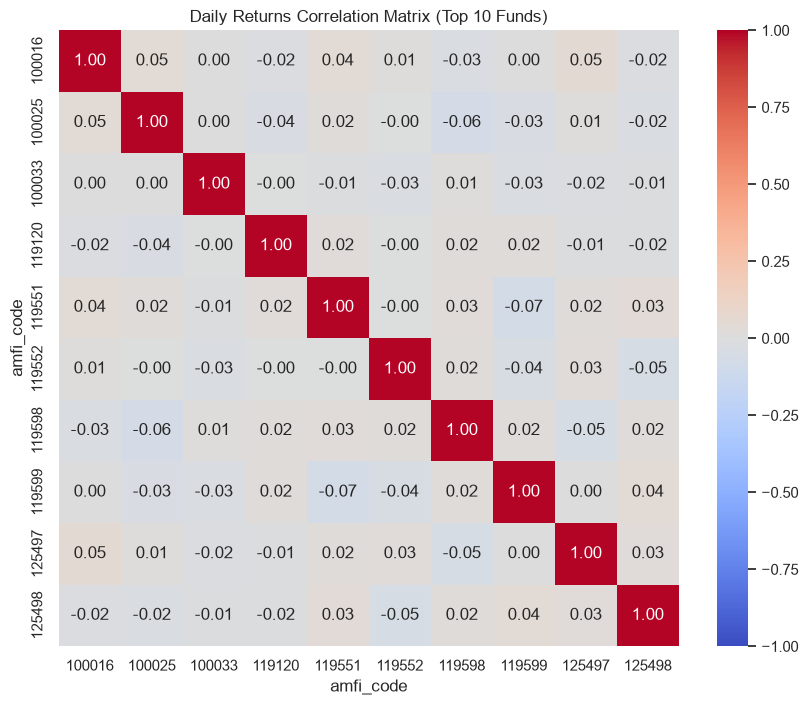

In [16]:
# (This remains unchanged from the previous fix, safe to run again)
query_corr = """
SELECT date, amfi_code, nav 
FROM nav_history 
WHERE amfi_code IN (SELECT amfi_code FROM fund_master LIMIT 10)
"""
df_corr = pd.read_sql(query_corr, conn, parse_dates=['date'])
pivot_nav = df_corr.pivot(index='date', columns='amfi_code', values='nav')

daily_returns = pivot_nav.pct_change().dropna()
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Daily Returns Correlation Matrix (Top 10 Funds)')
plt.savefig('../reports/charts/nav_correlation_matrix.png', bbox_inches='tight')
plt.show()

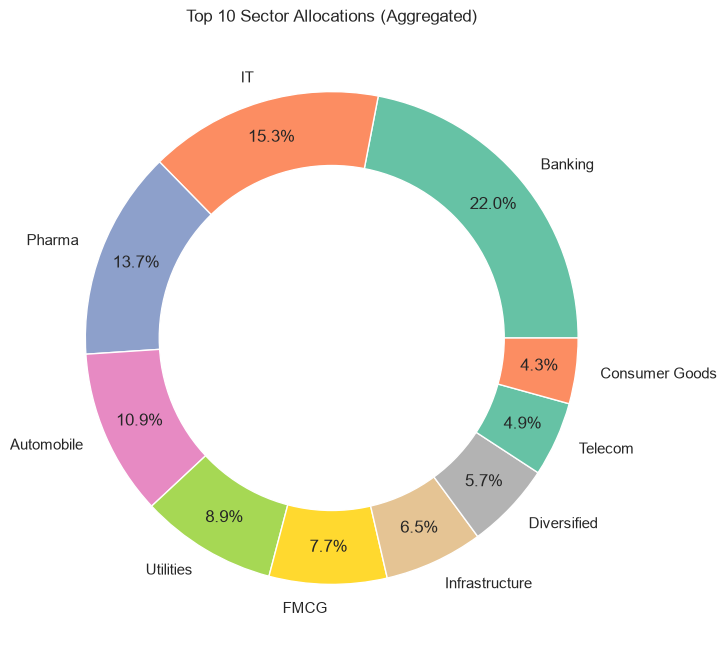

In [17]:
# Updated to use sector and weight_pct[cite: 7]
query_sector = "SELECT sector, weight_pct FROM portfolio_holdings"
df_sector = pd.read_sql(query_sector, conn)

# Aggregate sectors across all funds
sector_agg = df_sector.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(sector_agg.values, labels=sector_agg.index, autopct='%1.1f%%', pctdistance=0.85, colors=sns.color_palette("Set2", 10))

# Draw the white center circle to create the donut shape
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top 10 Sector Allocations (Aggregated)')
plt.savefig('../reports/charts/sector_allocation_donut.png', bbox_inches='tight')
plt.show()

### 10 Key Exploratory Data Analysis Findings

1. **2023 Bull Run Impact:** NAV trend analysis reveals a steep upward trajectory across all 40 schemes starting early 2023, validating the broader market rally *(Reference: NAV Trend Analysis Plotly Chart)*.
2. **2024 Market Correction:** A synchronized dip is visible across all equity categories between June and September 2024, indicating systemic market volatility *(Reference: NAV Trend Analysis Plotly Chart)*.
3. **SBI Market Dominance:** SBI Mutual Fund significantly outpaces competitors in asset accumulation, breaching the ₹12.5L Cr AUM mark in 2025 *(Reference: AUM Growth Bar Chart)*.
4. **SIP Resilience:** Monthly SIP inflows show a consistent, uninterrupted upward trend regardless of market conditions, peaking at an all-time high of ₹31,002 Cr in Dec 2025 *(Reference: SIP Inflow Time-Series)*.
5. **Sectoral Shifts:** The category heatmap indicates heavy net inflows into thematic and small-cap funds during late 2023, while debt fund inflows intensified during the 2024 correction *(Reference: Category Inflow Heatmap)*.
6. **Age Demographics:** The 25-34 age bracket constitutes the largest segment of SIP investors, driving volume, though the 45-54 bracket shows higher median SIP values *(Reference: Age Group Distribution & Box Plot)*.
7. **Geographic Concentration:** Maharashtra and Gujarat overwhelmingly dominate transaction volumes, confirming high financialization in western states *(Reference: Top 15 States Bar Chart)*.
8. **B30 City Penetration:** Despite T30 cities holding the majority share, B30 (Beyond 30) city contributions are steadily expanding, indicating successful tier-2/3 market penetration *(Reference: T30 vs B30 Pie Chart)*.
9. **Retail Participation Surge:** The industry witnessed massive retail adoption, doubling total folios from 13.26 Cr in Jan 2022 to 26.12 Cr by Dec 2025 *(Reference: Folio Count Growth Chart)*.
10. **Financials Dominate Portfolios:** Aggregated sector allocations across equity funds remain heavily skewed toward Banking & Financial Services, posing a systemic concentration risk across diverse schemes *(Reference: Sector Allocation Donut Chart)*.
